<a href="https://colab.research.google.com/github/Kavindi12/Computer-Vision-CW---DR-Stage-Detection/blob/main/Computer_Vision_CW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os

BASE_DIR = '/content/drive/MyDrive/DR_CW'

SUB_FOLDERS = ['data/raw', 'data/processed_224', 'models', 'figures', 'report']

for folder in SUB_FOLDERS:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

FIG_DIR = os.path.join(BASE_DIR, 'figures')
print('Project folders ready under:', BASE_DIR)

Project folders ready under: /content/drive/MyDrive/DR_CW


In [14]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version :', tf.__version__)
print('GPU devices        :', tf.config.list_physical_devices('GPU'))

TensorFlow version : 2.20.0
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
!pip install -q --upgrade kaggle

In [16]:
import getpass
import pathlib

token = getpass.getpass('Paste your Kaggle token: ').strip()

print('length:', len(token), '(expected 37)   starts with KGAT_:', token.startswith('KGAT_'))

kaggle_dir = pathlib.Path.home() / '.kaggle'
kaggle_dir.mkdir(exist_ok=True)

token_file = kaggle_dir / 'access_token'
token_file.write_text(token)
token_file.chmod(0o600)

os.environ['KAGGLE_API_TOKEN'] = token

del token

Paste your Kaggle token: ··········
length: 37 (expected 37)   starts with KGAT_: True


In [17]:
!kaggle competitions list -s aptos

ref                                                                deadline             category       reward  teamCount  userHasEntered  userRank  
-----------------------------------------------------------------  -------------------  ---------  ----------  ---------  --------------  --------  
https://www.kaggle.com/competitions/aptos2019-blindness-detection  2019-09-07 23:59:00  Featured   50,000 Usd       2928            True         0  
https://www.kaggle.com/competitions/precio-aptos-medellin          2050-09-26 23:59:00  Community       Kudos         24           False         0  
https://www.kaggle.com/competitions/aptos                          2018-03-11 23:59:00  Community       Kudos         18           False         0  
https://www.kaggle.com/competitions/copy-of-2022-tzuchi-mi-2       2022-11-19 23:59:00  Community       Kudos          2           False         0  
https://www.kaggle.com/competitions/2022-tzuchi-mi                 2022-11-19 23:59:00  Community       Ku

In [18]:
ZIP_PATH = '/content/aptos/aptos2019-blindness-detection.zip'

if not os.path.exists(ZIP_PATH):
    !kaggle competitions download -c aptos2019-blindness-detection -p /content/aptos
else:
    print('Archive already downloaded.')

Archive already downloaded.


In [20]:
import zipfile

RAW_DIR = '/content/aptos_data'
IMG_DIR = os.path.join(RAW_DIR, 'train_images')

if not os.path.exists(IMG_DIR):
    with zipfile.ZipFile(ZIP_PATH) as archive:
        wanted = [name for name in archive.namelist()
                  if name.startswith('train_images/') or name == 'train.csv']
        archive.extractall(RAW_DIR, members=wanted)

print('Number of training images extracted:', len(os.listdir(IMG_DIR)))

Number of training images extracted: 3662


In [21]:
STAGE_NAMES = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative DR',
}

df = pd.read_csv(os.path.join(RAW_DIR, 'train.csv'))
df['stage'] = df['diagnosis'].map(STAGE_NAMES)
df['path'] = df['id_code'].apply(lambda code: os.path.join(IMG_DIR, code + '.png'))

missing = (~df['path'].apply(os.path.exists)).sum()
print('Total labelled images :', len(df))
print('Missing image files   :', missing)

df.to_csv(os.path.join(BASE_DIR, 'data/raw/train.csv'), index=False)
df.head()

Total labelled images : 3662
Missing image files   : 0


,id_code,diagnosis,stage,path
0,000c1434d8d7,2,Moderate,/content/aptos_data/train_images/000c1434d8d7.png
1,001639a390f0,4,Proliferative DR,/content/aptos_data/train_images/001639a390f0.png
2,0024cdab0c1e,1,Mild,/content/aptos_data/train_images/0024cdab0c1e.png
3,002c21358ce6,0,No DR,/content/aptos_data/train_images/002c21358ce6.png
4,005b95c28852,0,No DR,/content/aptos_data/train_images/005b95c28852.png


           stage  images  percent
           No DR    1805     49.3
            Mild     370     10.1
        Moderate     999     27.3
          Severe     193      5.3
Proliferative DR     295      8.1


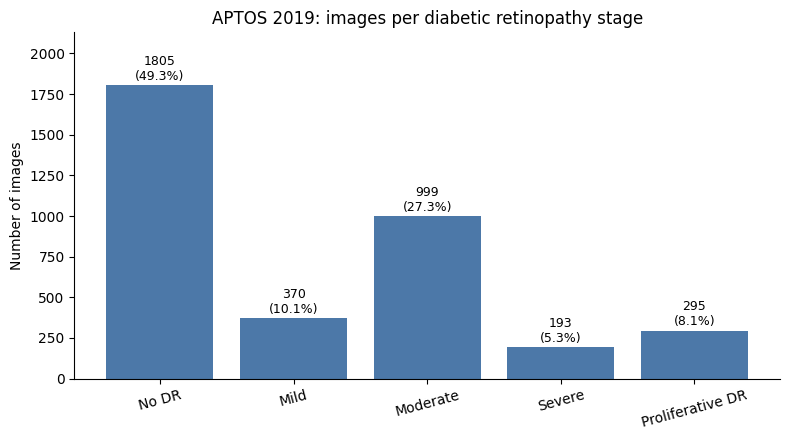

Imbalance ratio (largest class / smallest class): 9.4 to 1


In [22]:
counts = df['diagnosis'].value_counts().sort_index()
percentages = (counts / counts.sum() * 100).round(1)

distribution = pd.DataFrame({
    'stage': [STAGE_NAMES[i] for i in counts.index],
    'images': counts.values,
    'percent': percentages.values,
})
print(distribution.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([STAGE_NAMES[i] for i in counts.index], counts.values, color='#4C78A8')

for bar, value, pct in zip(bars, counts.values, percentages.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 15,
            f'{value}\n({pct}%)', ha='center', va='bottom', fontsize=9)

ax.set_title('APTOS 2019: images per diabetic retinopathy stage')
ax.set_ylabel('Number of images')
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, 'fig01_class_distribution.png'), dpi=300)
plt.show()

print('Imbalance ratio (largest class / smallest class): '
      f'{counts.max() / counts.min():.1f} to 1')

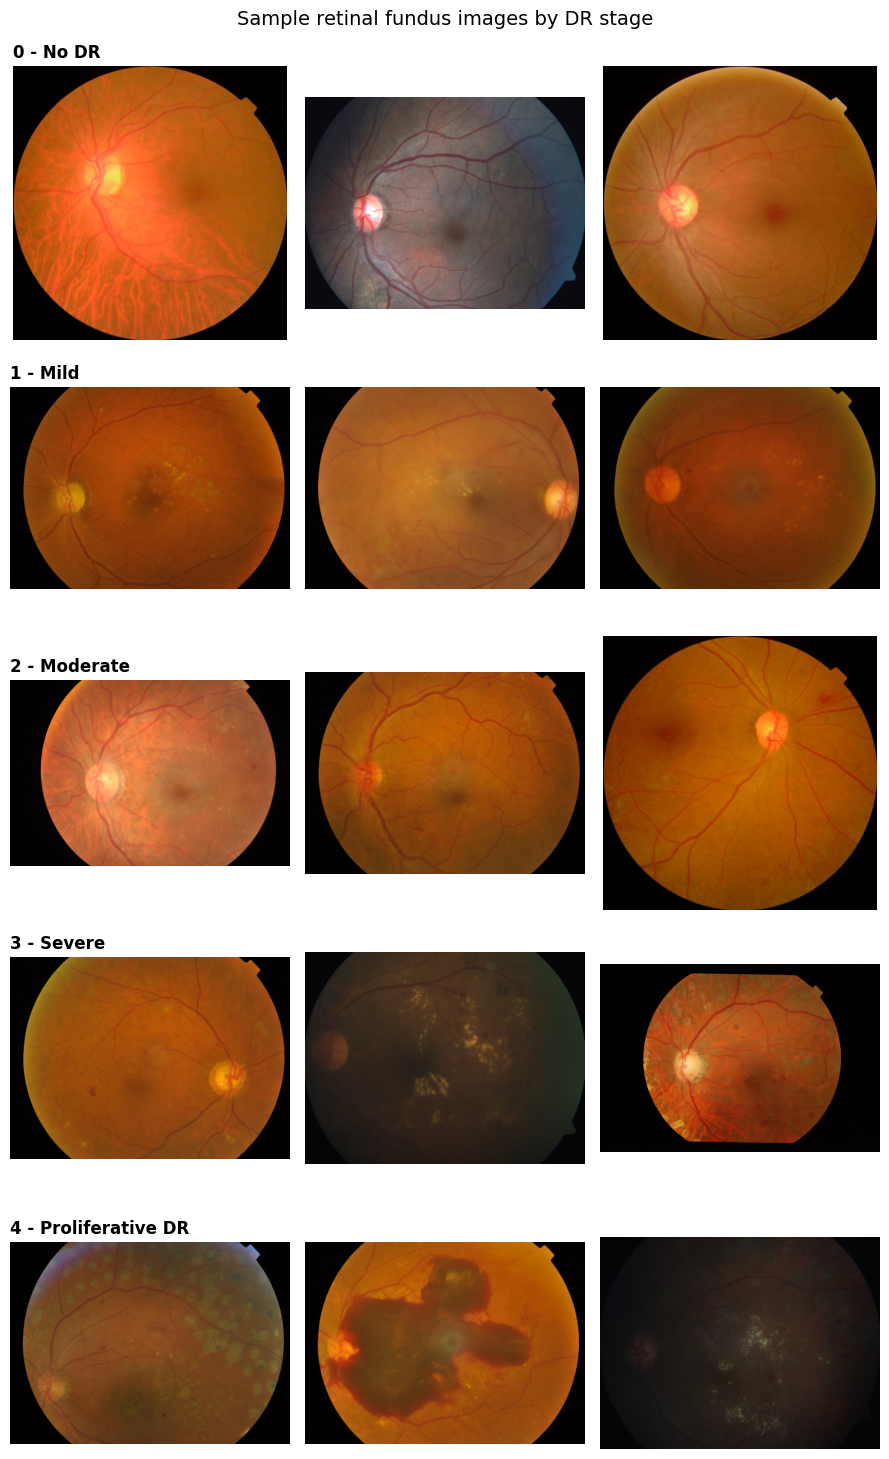

In [23]:
def load_rgb(path):
    """Read an image from disk and convert it from OpenCV's BGR order to RGB for plotting."""
    image = cv2.imread(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


SAMPLES_PER_STAGE = 3
fig, axes = plt.subplots(5, SAMPLES_PER_STAGE, figsize=(3 * SAMPLES_PER_STAGE, 15))

for row, stage in enumerate(sorted(STAGE_NAMES)):
    sample = df[df['diagnosis'] == stage].sample(SAMPLES_PER_STAGE, random_state=SEED)
    for col, (_, record) in enumerate(sample.iterrows()):
        axes[row, col].imshow(load_rgb(record['path']))
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f"{stage} - {STAGE_NAMES[stage]}",
                                     loc='left', fontsize=12, fontweight='bold')

plt.suptitle('Sample retinal fundus images by DR stage', fontsize=14, y=0.99)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig02_sample_images.png'), dpi=200)
plt.show()

        width  height  aspect
count   300.0   300.0   300.0
mean   2017.2  1534.0     1.3
std     911.8   557.0     0.2
min     474.0   358.0     1.0
25%    1050.0  1050.0     1.0
50%    2048.0  1536.0     1.3
75%    2588.0  1958.0     1.4
max    4288.0  2848.0     1.5

Most common resolutions:
1050 x 1050    87
2588 x 1958    46
3216 x 2136    39
2416 x 1736    39
2048 x 1536    28
Name: count, dtype: int64


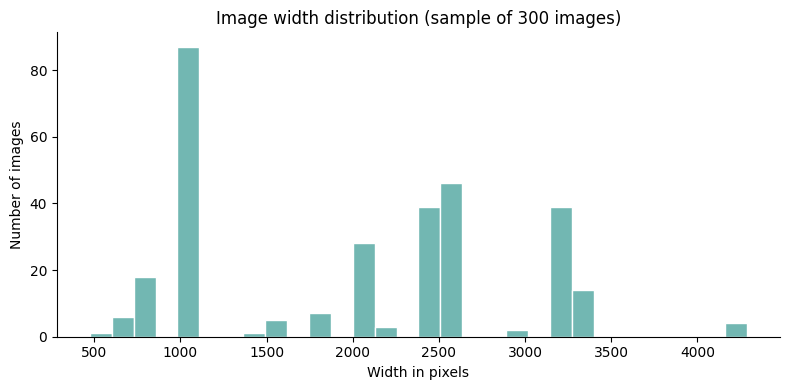

In [24]:
sample_paths = df['path'].sample(300, random_state=SEED)

sizes = []
for path in sample_paths:
    height, width = cv2.imread(path).shape[:2]
    sizes.append({'width': width, 'height': height, 'aspect': round(width / height, 2)})

sizes = pd.DataFrame(sizes)
print(sizes.describe().round(1).to_string())
print('\nMost common resolutions:')
print((sizes['width'].astype(str) + ' x ' + sizes['height'].astype(str)).value_counts().head())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sizes['width'], bins=30, color='#72B7B2', edgecolor='white')
ax.set_title('Image width distribution (sample of 300 images)')
ax.set_xlabel('Width in pixels')
ax.set_ylabel('Number of images')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig03_image_sizes.png'), dpi=300)
plt.show()